# Coastal bearing point by point

In [1]:
import xarray as xr
import numpy as np
from scipy.ndimage import binary_erosion, binary_dilation
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
lati1,lati2=-4,-17
R_X = xr.open_dataset('Rossby_radius_and_X.nc').lat; step = R_X.sel(lat=slice(lati2,lati1)).shape[0]
step

159

In [3]:
# ============================================================
# 1. Load wind data and CROCO grid
# ============================================================
winds_ds = xr.open_dataset('winds_NHUS.nc').compute()

ds = xr.open_dataset('../../../NHCS/hincast_1980-2015/croco_avg_Y1980M01.nc',
                     chunks={'time': 1})

mask     = ds['mask_rho'].values     # 1=ocean, 0=land
lon_grid = ds['lon_rho'].values      # 2D
lat_grid = ds['lat_rho'].values      # 2D

# ============================================================
# 2. Extract coastal points (easternmost ocean cell per row)
# ============================================================
coast_lon_list = []
coast_lat_list = []

for j in range(mask.shape[0]):
    row = mask[j, :]
    ocean_cols = np.where(row == 1)[0]
    if len(ocean_cols) == 0:
        continue
    i = ocean_cols[-1]
    coast_lon_list.append(lon_grid[j, i])
    coast_lat_list.append(lat_grid[j, i])

coast_lon_all = np.array(coast_lon_list)
coast_lat_all = np.array(coast_lat_list)

# Filter to 5°S–16°S
domain = (coast_lat_all >= lati2) & (coast_lat_all <= lati1)
coast = {
    'lat': coast_lat_all[domain],
    'lon': coast_lon_all[domain],
}
print(f"Coastal points in 5°S–16°S: {len(coast['lat'])}")

# ============================================================
# 3. Extract coastal strips (n cells offshore per coastal point)
# ============================================================
lat = winds_ds.lat.values     # 1D
lon = winds_ds.lon.values     # 1D
u   = winds_ds.u10.values     # (time, lat, lon)
v   = winds_ds.v10.values

n = 10
lonc = np.empty((len(coast['lat']), n))
latc = np.empty((len(coast['lat']), n))
uc   = np.empty((u.shape[0], len(coast['lat']), n))
vc   = np.empty((v.shape[0], len(coast['lat']), n))

for point_idx, (lat_val, lon_val) in enumerate(zip(coast['lat'], coast['lon'])):
    lat_idx = np.abs(lat - lat_val).argmin()
    lon_idx = np.abs(lon - lon_val).argmin()
    uc[:, point_idx, :]  = u[:, lat_idx, int(lon_idx-n):int(lon_idx)]
    vc[:, point_idx, :]  = v[:, lat_idx, int(lon_idx-n):int(lon_idx)]
    lonc[point_idx, :]   = lon[int(lon_idx-n):int(lon_idx)]
    latc[point_idx, :]   = lat[lat_idx]

uc[np.abs(uc) > 100] = np.nan
vc[np.abs(vc) > 100] = np.nan

# ============================================================
# 4. Local coastline bearing
# ============================================================
def calculate_bearing(lat1, lon1, lat2, lon2):
    lat1_rad = np.deg2rad(lat1)
    lat2_rad = np.deg2rad(lat2)
    lon1_rad = np.deg2rad(lon1)
    lon2_rad = np.deg2rad(lon2)

    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad

    x = delta_lon * np.cos((lat1_rad + lat2_rad) / 2)
    y = delta_lat

    bearing_rad = np.arctan2(y, x)
    bearing_deg = (np.rad2deg(bearing_rad) + 360) % 360
    return bearing_deg


point_num = len(coast['lat'])
coast_orientation = np.empty(point_num)

for i in range(point_num):
    if i < point_num - 1:
        lat1 = coast['lat'][i]
        lon1 = coast['lon'][i]
        lat2 = coast['lat'][i+1]
        lon2 = coast['lon'][i+1]
    else:
        lat1 = coast['lat'][i-1]
        lon1 = coast['lon'][i-1]
        lat2 = coast['lat'][i]
        lon2 = coast['lon'][i]

    coast_orientation[i] = calculate_bearing(lat1, lon1, lat2, lon2)

# ============================================================
# 5. Project winds onto local along-coast unit vector
# ============================================================
coast_orientation_rad = np.deg2rad(coast_orientation)
u_alongshore_unit = np.cos(coast_orientation_rad).reshape(1, point_num, 1)
v_alongshore_unit = np.sin(coast_orientation_rad).reshape(1, point_num, 1)
wind_alongshore = uc * u_alongshore_unit + vc * v_alongshore_unit  # (time, coast, n)

# ============================================================
# 6. Distances from each coastal point to its strip cells
# ============================================================
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1_rad = np.deg2rad(lat1)
    lon1_rad = np.deg2rad(lon1)
    lat2_rad = np.deg2rad(lat2)
    lon2_rad = np.deg2rad(lon2)
    delta_lat = lat2_rad - lat1_rad
    delta_lon = lon2_rad - lon1_rad
    a = (np.sin(delta_lat / 2.0) ** 2
         + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon / 2.0) ** 2)
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


coast_lon_arr = np.array(coast['lon'])
coast_lat_arr = np.array(coast['lat'])
coast_lon_expanded = coast_lon_arr[:, np.newaxis]
coast_lat_expanded = coast_lat_arr[:, np.newaxis]

distances = haversine(coast_lat_expanded, coast_lon_expanded, latc, lonc)  # (coast, n)


Coastal points in 5°S–16°S: 159


In [8]:
uc.shape

(432, 159, 10)

In [9]:
distances

array([[88616.84659238, 79755.17334154, 70893.49648798, ...,
        26585.07219087, 17723.38212772,  8861.691264  ],
       [88654.42926878, 79788.99765145, 70923.56246263, ...,
        26596.34683599, 17730.89855201,  8865.44947441],
       [88691.85625128, 79822.68183714, 70953.50388263, ...,
        26607.57477338, 17738.38383784,  8869.1921156 ],
       ...,
       [92408.17596722, 83167.35913383, 73926.54205937, ...,
        27722.45400879, 18481.6360505 ,  9240.81803864],
       [92418.02861454, 83176.22648695, 73934.42412761, ...,
        27725.40975595, 18483.60654688,  9241.80328631],
       [92427.68784835, 83184.91976849, 73942.151466  , ...,
        27728.30747997, 18485.5383612 ,  9242.76919297]])

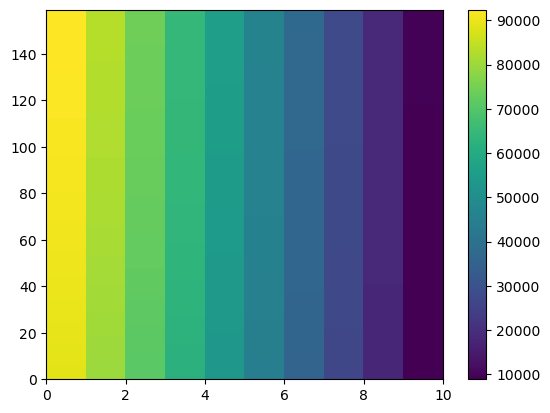

In [6]:
plt.pcolor(distances)
plt.colorbar()